In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib
print(matplotlib.__version__)

engine = create_engine("bigquery://olist-data-pipeline-507001")

3.11.0


In [ ]:
# Query to get monthly sales by product category for the year 2018

query_2018_monthly_categories = """
SELECT
  EXTRACT(MONTH FROM o.order_purchase_timestamp) AS month,
  p.product_category_name_english,
  SUM(oi.price + oi.freight_value) AS total_sales_value
FROM `olist-data-pipeline-507001.olist_mart.fact_order_items` oi
JOIN `olist-data-pipeline-507001.olist_mart.fact_orders` o
  ON oi.order_key = o.order_key
JOIN `olist-data-pipeline-507001.olist_mart.dim_product` p
  ON oi.product_id = p.product_id
WHERE o.order_status = 'DELIVERED'
  AND EXTRACT(YEAR FROM o.order_purchase_timestamp) = 2018
GROUP BY
  month,
  p.product_category_name_english
ORDER BY
  month,
  total_sales_value DESC
"""

category_sales_2018_monthly = pd.read_sql(
    query_2018_monthly_categories,
    engine
)

category_sales_2018_monthly

/home/nivedha/miniconda3/lib/python3.14/site-packages/google/cloud/bigquery/client.py:623: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


,month,product_category_name_english,total_sales_value
0,1,sports_leisure,86172.83
1,1,computers_accessories,80503.87
2,1,bed_bath_table,75408.13
3,1,watches_gifts,73521.24
4,1,health_beauty,71405.60
...,...,...,...
520,8,diapers_and_hygiene,231.89
521,8,fashion_underwear_beach,160.00
522,8,fashio_female_clothing,129.97
523,8,fashion_sport,69.90


In [ ]:
top_10_each_month_2018 = (
    category_sales_2018_monthly
    .groupby("month")
    .head(10)
)

top_10_each_month_2018

,month,product_category_name_english,total_sales_value
0,1,sports_leisure,86172.83
1,1,computers_accessories,80503.87
2,1,bed_bath_table,75408.13
3,1,watches_gifts,73521.24
4,1,health_beauty,71405.60
...,...,...,...
466,8,auto,45032.58
467,8,furniture_decor,41168.55
468,8,computers_accessories,40052.64
469,8,telephony,36572.91


In [ ]:
category_frequency_2018 = (
    top_10_each_month_2018
    .groupby("product_category_name_english")
    .size()
    .sort_values(ascending=False)
)

category_frequency_2018

product_category_name_english
auto                     8
bed_bath_table           8
furniture_decor          8
computers_accessories    8
housewares               8
health_beauty            8
watches_gifts            8
sports_leisure           8
cool_stuff               4
baby                     4
garden_tools             3
perfumery                2
telephony                2
stationery               1
dtype: int64

In [ ]:
# 
category_summary_2018 = (
    category_sales_2018_monthly
    .groupby("product_category_name_english", as_index=False)
    .agg(
        total_revenue=("total_sales_value", "sum")
    )
    .merge(
        category_frequency_2018.rename("top_10_months").reset_index(),
        on="product_category_name_english",
        how="left"
    )
)

category_summary_2018

,product_category_name_english,total_revenue,top_10_months
0,agro_industry_and_commerce,41386.90,NaN
1,air_conditioning,24705.06,NaN
2,art,14675.96,NaN
3,arts_and_craftmanship,1662.12,NaN
4,audio,32960.94,NaN
...,...,...,...
65,stationery,132315.75,1.0
66,tablets_printing_image,1267.96,NaN
67,telephony,174123.68,2.0
68,toys,168123.27,NaN


In [ ]:
# fill NaN values in the "top_10_months" column with 0 and convert to integer
category_summary_2018["top_10_months"] = (
    category_summary_2018["top_10_months"]
    .fillna(0)
    .astype(int)
)

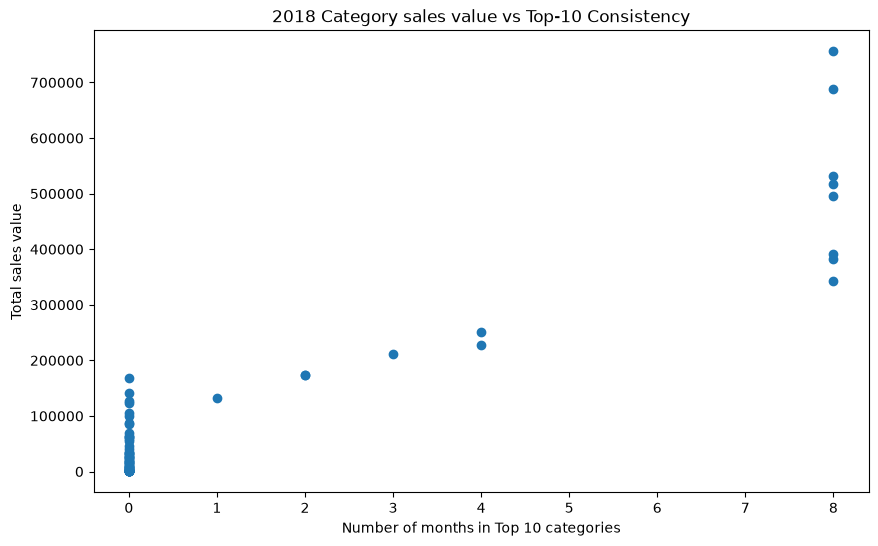

In [ ]:


plt.figure(figsize=(10, 6))

plt.scatter(
    category_summary_2018["top_10_months"],
    category_summary_2018["total_revenue"]
)

plt.xlabel("Number of months in Top 10 categories")
plt.ylabel("Total sales value")
plt.title("2018 Category sales value vs Top-10 Consistency")

plt.show()

In [ ]:
query_2017_monthly_categories = """

SELECT
  EXTRACT(MONTH FROM o.order_purchase_timestamp) AS month,
  p.product_category_name_english,
  SUM(oi.price + oi.freight_value) AS total_sales_value

FROM `olist-data-pipeline-507001.olist_mart.fact_order_items` oi

JOIN `olist-data-pipeline-507001.olist_mart.fact_orders` o
  ON oi.order_key = o.order_key

JOIN `olist-data-pipeline-507001.olist_mart.dim_product` p
  ON oi.product_id = p.product_id

WHERE o.order_status = 'DELIVERED'
  AND EXTRACT(YEAR FROM o.order_purchase_timestamp) = 2017

GROUP BY
  month,
  p.product_category_name_english

ORDER BY
  month,
  total_sales_value DESC

"""

category_sales_2017_monthly = pd.read_sql(
    query_2017_monthly_categories,
    engine
)

category_sales_2017_monthly

/home/nivedha/miniconda3/lib/python3.14/site-packages/google/cloud/bigquery/client.py:623: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


,month,product_category_name_english,total_sales_value
0,1,furniture_decor,13036.63
1,1,health_beauty,12366.44
2,1,sports_leisure,9212.14
3,1,watches_gifts,8086.52
4,1,garden_tools,7466.95
...,...,...,...
702,12,art,115.25
703,12,flowers,82.70
704,12,diapers_and_hygiene,76.00
705,12,cds_dvds_musicals,65.00


In [ ]:
category_sales_2017_monthly["half_year"] = (
    category_sales_2017_monthly["month"]
    .apply(lambda x: "H1 (Jan-Jun)" if x <= 6 else "H2 (Jul-Dec)")
)

category_sales_2017_monthly

,month,product_category_name_english,total_sales_value,half_year
0,1,furniture_decor,13036.63,H1 (Jan-Jun)
1,1,health_beauty,12366.44,H1 (Jan-Jun)
2,1,sports_leisure,9212.14,H1 (Jan-Jun)
3,1,watches_gifts,8086.52,H1 (Jan-Jun)
4,1,garden_tools,7466.95,H1 (Jan-Jun)
...,...,...,...,...
702,12,art,115.25,H2 (Jul-Dec)
703,12,flowers,82.70,H2 (Jul-Dec)
704,12,diapers_and_hygiene,76.00,H2 (Jul-Dec)
705,12,cds_dvds_musicals,65.00,H2 (Jul-Dec)


In [ ]:
top_10_each_month_2017 = (
    category_sales_2017_monthly
    .sort_values(["month", "total_sales_value"], ascending=[True, False])
    .groupby("month")
    .head(10)
)

top_10_each_month_2017

,month,product_category_name_english,total_sales_value,half_year
0,1,furniture_decor,13036.63,H1 (Jan-Jun)
1,1,health_beauty,12366.44,H1 (Jan-Jun)
2,1,sports_leisure,9212.14,H1 (Jan-Jun)
3,1,watches_gifts,8086.52,H1 (Jan-Jun)
4,1,garden_tools,7466.95,H1 (Jan-Jun)
...,...,...,...,...
649,12,auto,39019.96,H2 (Jul-Dec)
650,12,cool_stuff,37515.57,H2 (Jul-Dec)
651,12,computers_accessories,37428.67,H2 (Jul-Dec)
652,12,furniture_decor,31073.09,H2 (Jul-Dec)


In [ ]:
category_frequency_2017 = (
    top_10_each_month_2017
    .groupby(["half_year", "product_category_name_english"])
    .size()
    .reset_index(name="top_10_months")
)

category_frequency_2017

,half_year,product_category_name_english,top_10_months
0,H1 (Jan-Jun),auto,4
1,H1 (Jan-Jun),baby,1
2,H1 (Jan-Jun),bed_bath_table,5
3,H1 (Jan-Jun),computers_accessories,5
4,H1 (Jan-Jun),cool_stuff,6
5,H1 (Jan-Jun),furniture_decor,6
6,H1 (Jan-Jun),garden_tools,5
7,H1 (Jan-Jun),health_beauty,6
8,H1 (Jan-Jun),housewares,3
9,H1 (Jan-Jun),perfumery,4


In [ ]:
half_year_revenue_2017 = (
    category_sales_2017_monthly
    .groupby(
        ["half_year", "product_category_name_english"],
        as_index=False
    )
    .agg(
        total_revenue=("total_sales_value", "sum")
    )
)

half_year_revenue_2017

,half_year,product_category_name_english,total_revenue
0,H1 (Jan-Jun),agro_industry_and_commerce,3342.74
1,H1 (Jan-Jun),air_conditioning,12664.39
2,H1 (Jan-Jun),art,7422.05
3,H1 (Jan-Jun),arts_and_craftmanship,21.99
4,H1 (Jan-Jun),audio,5992.95
...,...,...,...
132,H2 (Jul-Dec),stationery,68021.74
133,H2 (Jul-Dec),tablets_printing_image,1751.59
134,H2 (Jul-Dec),telephony,97641.80
135,H2 (Jul-Dec),toys,222239.28


In [ ]:
category_summary_2017 = (
    half_year_revenue_2017
    .merge(
        category_frequency_2017,
        on=["half_year", "product_category_name_english"],
        how="left"
    )
)

category_summary_2017["top_10_months"] = (
    category_summary_2017["top_10_months"]
    .fillna(0)
    .astype(int)
)



,half_year,product_category_name_english,total_revenue,top_10_months
0,H1 (Jan-Jun),agro_industry_and_commerce,3342.74,0
1,H1 (Jan-Jun),air_conditioning,12664.39,0
2,H1 (Jan-Jun),art,7422.05,0
3,H1 (Jan-Jun),arts_and_craftmanship,21.99,0
4,H1 (Jan-Jun),audio,5992.95,0
...,...,...,...,...
132,H2 (Jul-Dec),stationery,68021.74,0
133,H2 (Jul-Dec),tablets_printing_image,1751.59,0
134,H2 (Jul-Dec),telephony,97641.80,0
135,H2 (Jul-Dec),toys,222239.28,5


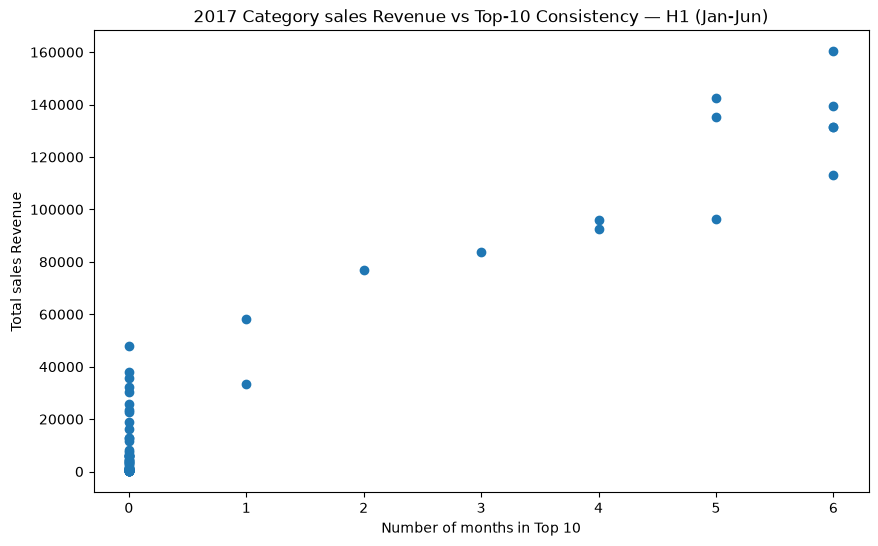

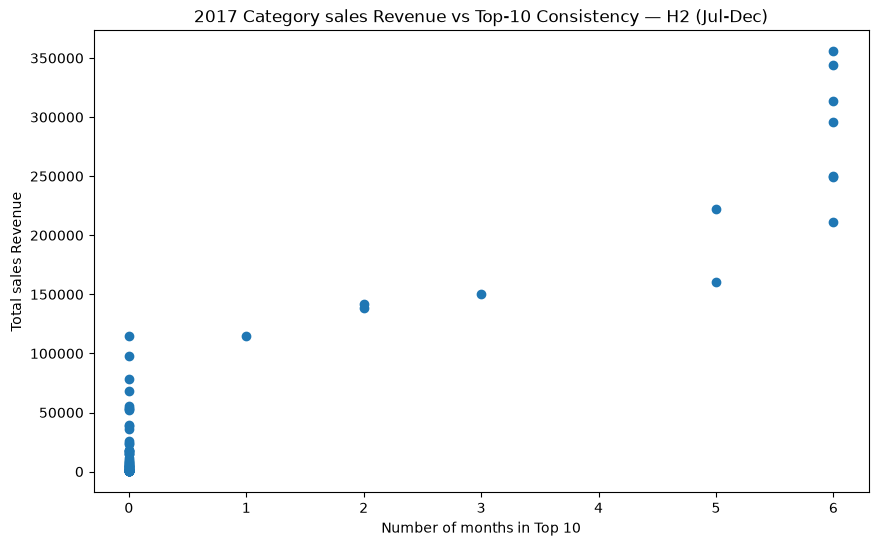

In [ ]:
import matplotlib.pyplot as plt

for half in ["H1 (Jan-Jun)", "H2 (Jul-Dec)"]:

    data = category_summary_2017[
        category_summary_2017["half_year"] == half
    ]

    plt.figure(figsize=(10, 6))

    plt.scatter(
        data["top_10_months"],
        data["total_revenue"]
    )

    plt.xlabel("Number of months in Top 10")
    plt.ylabel("Total sales Revenue")
    plt.title(f"2017 Category sales Revenue vs Top-10 Consistency — {half}")

    plt.show()

In [ ]:
category_revenue_2018 = (
    category_sales_2018_monthly
    .groupby("product_category_name_english", as_index=False)
    .agg(
        revenue_2018=("total_sales_value", "sum")
    )
)

category_revenue_2018

,product_category_name_english,revenue_2018
0,agro_industry_and_commerce,41386.90
1,air_conditioning,24705.06
2,art,14675.96
3,arts_and_craftmanship,1662.12
4,audio,32960.94
...,...,...
65,stationery,132315.75
66,tablets_printing_image,1267.96
67,telephony,174123.68
68,toys,168123.27


In [ ]:
category_revenue_2017 = (
    category_sales_2017_monthly
    .groupby("product_category_name_english", as_index=False)
    .agg(
        revenue_2017=("total_sales_value", "sum")
    )
)

category_revenue_2017

,product_category_name_english,revenue_2017
0,agro_industry_and_commerce,29179.20
1,air_conditioning,27269.21
2,art,8981.34
3,arts_and_craftmanship,151.89
4,audio,17452.67
...,...,...
66,stationery,91472.94
67,tablets_printing_image,6260.45
68,telephony,135508.26
69,toys,299056.71


In [ ]:
category_revenue_comparison = (
    category_revenue_2017
    .merge(
        category_revenue_2018,
        on="product_category_name_english",
        how="outer"
    )
    .fillna(0)
)

category_revenue_comparison

,product_category_name_english,revenue_2017,revenue_2018
0,agro_industry_and_commerce,29179.20,41386.90
1,air_conditioning,27269.21,24705.06
2,art,8981.34,14675.96
3,arts_and_craftmanship,151.89,1662.12
4,audio,17452.67,32960.94
...,...,...,...
66,stationery,91472.94,132315.75
67,tablets_printing_image,6260.45,1267.96
68,telephony,135508.26,174123.68
69,toys,299056.71,168123.27


In [ ]:
category_sales_2017_jan_aug = (
    category_sales_2017_monthly[
        category_sales_2017_monthly["month"] <= 8
    ]
)

category_sales_2017_jan_aug

,month,product_category_name_english,total_sales_value,half_year
0,1,furniture_decor,13036.63,H1 (Jan-Jun)
1,1,health_beauty,12366.44,H1 (Jan-Jun)
2,1,sports_leisure,9212.14,H1 (Jan-Jun)
3,1,watches_gifts,8086.52,H1 (Jan-Jun)
4,1,garden_tools,7466.95,H1 (Jan-Jun)
...,...,...,...,...
443,8,books_imported,61.00,H2 (Jul-Dec)
444,8,christmas_supplies,58.90,H2 (Jul-Dec)
445,8,home_comfort_2,38.70,H2 (Jul-Dec)
446,8,small_appliances_home_oven_and_coffee,21.90,H2 (Jul-Dec)


In [ ]:
category_revenue_2017_jan_aug = (
    category_sales_2017_jan_aug
    .groupby("product_category_name_english", as_index=False)
    .agg(
        revenue_2017=("total_sales_value", "sum")
    )
)

category_revenue_2017_jan_aug

,product_category_name_english,revenue_2017
0,agro_industry_and_commerce,4610.74
1,air_conditioning,18332.22
2,art,8053.50
3,arts_and_craftmanship,151.89
4,audio,7717.34
...,...,...
64,stationery,36724.96
65,tablets_printing_image,5157.75
66,telephony,57472.64
67,toys,118449.64


In [ ]:
c

,product_category_name_english,revenue_2017,revenue_2018
0,agro_industry_and_commerce,4610.74,41386.90
1,air_conditioning,18332.22,24705.06
2,art,8053.50,14675.96
3,arts_and_craftmanship,151.89,1662.12
4,audio,7717.34,32960.94
...,...,...,...
66,stationery,36724.96,132315.75
67,tablets_printing_image,5157.75,1267.96
68,telephony,57472.64,174123.68
69,toys,118449.64,168123.27


In [ ]:
category_revenue_comparison["revenue_change_percent"] = (
    (
        category_revenue_comparison["revenue_2018"]
        - category_revenue_comparison["revenue_2017"]
    )
    / category_revenue_comparison["revenue_2017"]
) * 100

category_revenue_comparison

,product_category_name_english,revenue_2017,revenue_2018,revenue_change_percent
0,agro_industry_and_commerce,4610.74,41386.90,797.619471
1,air_conditioning,18332.22,24705.06,34.763057
2,art,8053.50,14675.96,82.230831
3,arts_and_craftmanship,151.89,1662.12,994.291922
4,audio,7717.34,32960.94,327.102344
...,...,...,...,...
66,stationery,36724.96,132315.75,260.288343
67,tablets_printing_image,5157.75,1267.96,-75.416412
68,telephony,57472.64,174123.68,202.967951
69,toys,118449.64,168123.27,41.936497


In [ ]:
category_revenue_comparison["revenue_change"] = (
    category_revenue_comparison["revenue_2018"]
    - category_revenue_comparison["revenue_2017"]
)

category_revenue_comparison

,product_category_name_english,revenue_2017,revenue_2018,revenue_change_percent,revenue_change
0,agro_industry_and_commerce,4610.74,41386.90,797.619471,36776.16
1,air_conditioning,18332.22,24705.06,34.763057,6372.84
2,art,8053.50,14675.96,82.230831,6622.46
3,arts_and_craftmanship,151.89,1662.12,994.291922,1510.23
4,audio,7717.34,32960.94,327.102344,25243.60
...,...,...,...,...,...
66,stationery,36724.96,132315.75,260.288343,95590.79
67,tablets_printing_image,5157.75,1267.96,-75.416412,-3889.79
68,telephony,57472.64,174123.68,202.967951,116651.04
69,toys,118449.64,168123.27,41.936497,49673.63


In [ ]:
category_revenue_comparison.sort_values(
    "revenue_change",
    ascending=False
).head(10)

,product_category_name_english,revenue_2017,revenue_2018,revenue_change_percent,revenue_change
43,health_beauty,243521.70,755724.50,210.331482,512202.80
70,watches_gifts,201137.86,687855.20,241.981962,486717.34
65,sports_leisure,216724.33,517166.26,138.628612,300441.93
15,computers_accessories,214631.27,496269.30,131.219477,281638.03
7,bed_bath_table,254444.82,532358.85,109.223693,277914.03
49,housewares,127534.54,391823.46,207.229289,264288.92
5,auto,125247.48,343288.30,174.087990,218040.82
39,furniture_decor,170858.58,381649.57,123.371615,210790.99
6,baby,67998.26,250615.79,268.562063,182617.53
17,construction_tools_construction,2581.49,122886.61,4660.297735,120305.12


In [ ]:
category_revenue_comparison.sort_values(
    "revenue_change",
    ascending=True
).head(10)

,product_category_name_english,revenue_2017,revenue_2018,revenue_change_percent,revenue_change
54,market_place,15088.93,7565.57,-49.860129,-7523.36
67,tablets_printing_image,5157.75,1267.96,-75.416412,-3889.79
30,fashion_male_clothing,4644.28,2301.87,-50.436451,-2342.41
25,dvds_blu_ray,2995.79,1132.71,-62.189940,-1863.08
27,fashio_female_clothing,1547.70,616.66,-60.156361,-931.04
32,fashion_sport,1160.72,369.50,-68.166311,-791.22
47,home_confort,21445.47,20737.65,-3.300557,-707.82
31,fashion_shoes,8907.08,8296.97,-6.849720,-610.11
46,home_comfort_2,493.08,151.09,-69.357914,-341.99
11,cds_dvds_musicals,360.00,65.00,-81.944444,-295.00


In [ ]:
top_increases = (
    category_revenue_comparison
    .sort_values("revenue_change", ascending=False)
    .head(5)
)

top_decreases = (
    category_revenue_comparison
    .sort_values("revenue_change", ascending=True)
    .head(5)
)

comparison_chart_data = pd.concat([
    top_increases,
    top_decreases
])

comparison_chart_data

,product_category_name_english,revenue_2017,revenue_2018,revenue_change_percent,revenue_change
43,health_beauty,243521.70,755724.50,210.331482,512202.80
70,watches_gifts,201137.86,687855.20,241.981962,486717.34
65,sports_leisure,216724.33,517166.26,138.628612,300441.93
15,computers_accessories,214631.27,496269.30,131.219477,281638.03
7,bed_bath_table,254444.82,532358.85,109.223693,277914.03
54,market_place,15088.93,7565.57,-49.860129,-7523.36
67,tablets_printing_image,5157.75,1267.96,-75.416412,-3889.79
30,fashion_male_clothing,4644.28,2301.87,-50.436451,-2342.41
25,dvds_blu_ray,2995.79,1132.71,-62.189940,-1863.08
27,fashio_female_clothing,1547.70,616.66,-60.156361,-931.04


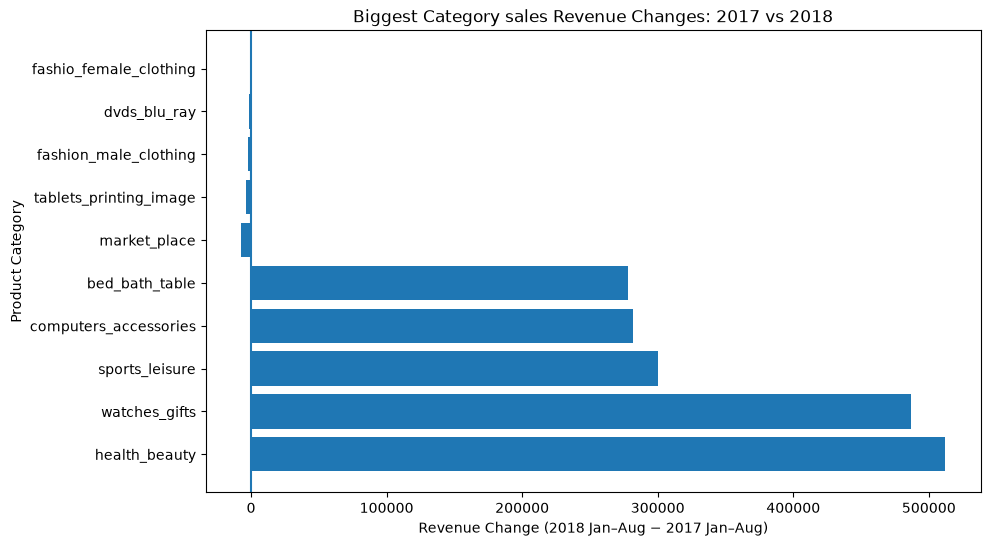

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    comparison_chart_data["product_category_name_english"],
    comparison_chart_data["revenue_change"]
)

plt.xlabel("Revenue Change (2018 Jan–Aug − 2017 Jan–Aug)")
plt.ylabel("Product Category")
plt.title("Biggest Category sales Revenue Changes: 2017 vs 2018")

plt.axvline(0)

plt.show()

In [ ]:
def plot_category_revenue_change(df):
    import matplotlib.pyplot as plt

    plot_data = df.sort_values("revenue_change")

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(
        plot_data["product_category_name_english"],
        plot_data["revenue_change"]
    )

    ax.axvline(0)

    ax.set_xlabel("Revenue Change (2018 Jan–Aug − 2017 Jan–Aug)")
    ax.set_ylabel("Product Category")
    ax.set_title("Biggest Category Revenue Changes: 2017 vs 2018")

    plt.tight_layout()

    return fig

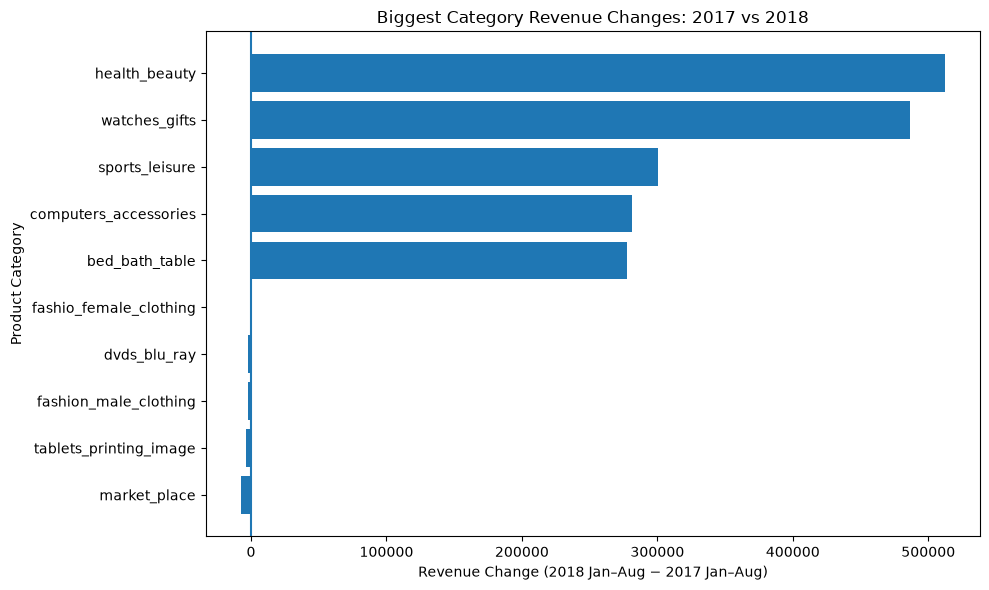

In [ ]:
fig = plot_category_revenue_change(comparison_chart_data)
plt.show()

In [ ]:
def plot_category_consistency(df):
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(
        df["top_10_months"],
        df["total_revenue"]
    )

    ax.set_xlabel("Number of Months in Top 10")
    ax.set_ylabel("Total 2018 Revenue")
    ax.set_title("2018 Category Revenue vs Top-10 Consistency")

    plt.tight_layout()

    return fig

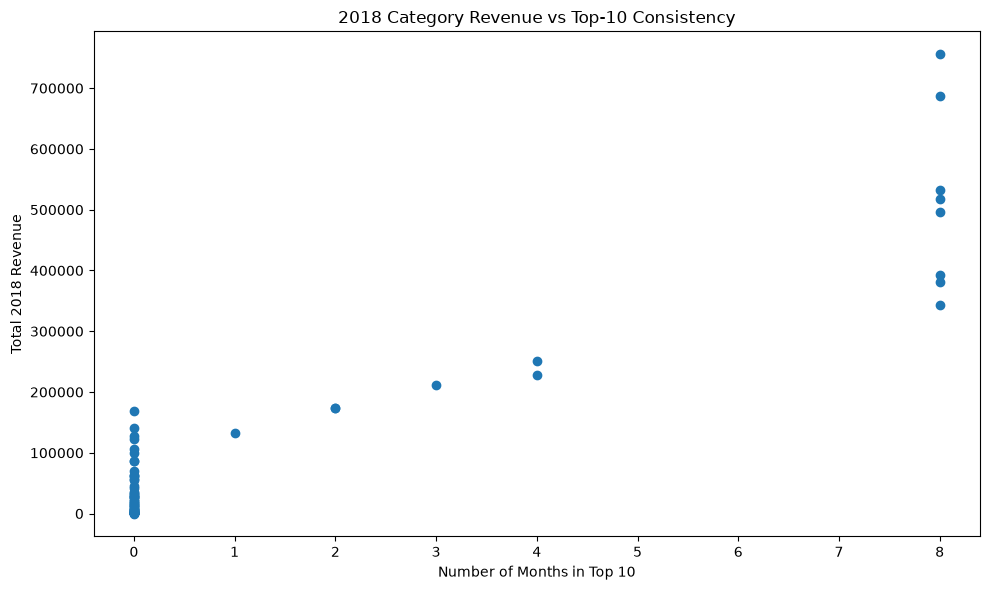

In [ ]:
fig = plot_category_consistency(category_summary_2018)
plt.show()

In [ ]:
def plot_2017_category_consistency(df, half_year):
    import matplotlib.pyplot as plt

    plot_data = df[df["half_year"] == half_year]

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(
        plot_data["top_10_months"],
        plot_data["total_revenue"]
    )

    ax.set_xlabel("Number of Months in Top 10")
    ax.set_ylabel("Total Revenue")
    ax.set_title(f"2017 Category Revenue vs Top-10 Consistency — {half_year}")

    plt.tight_layout()

    return fig

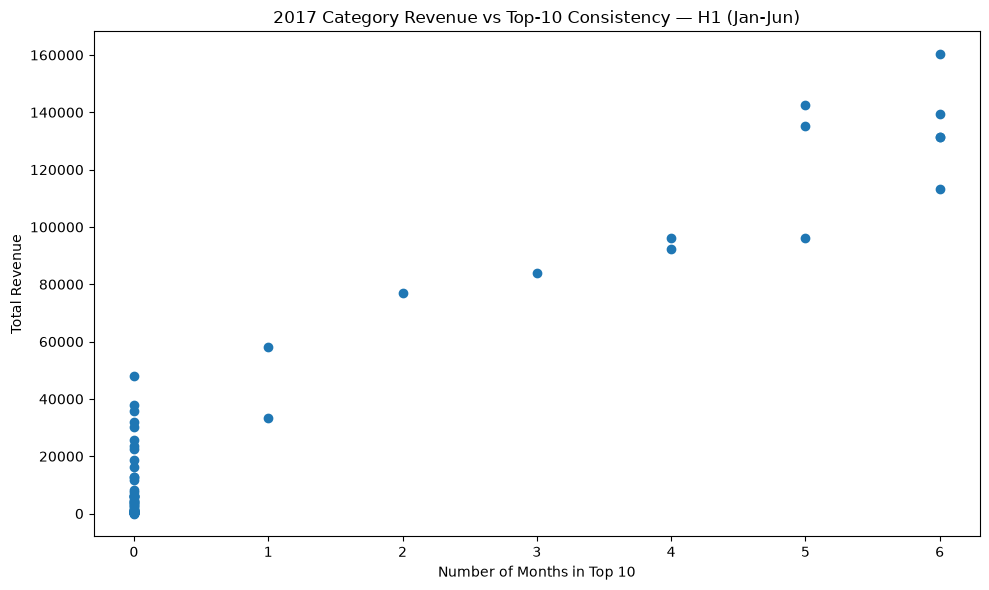

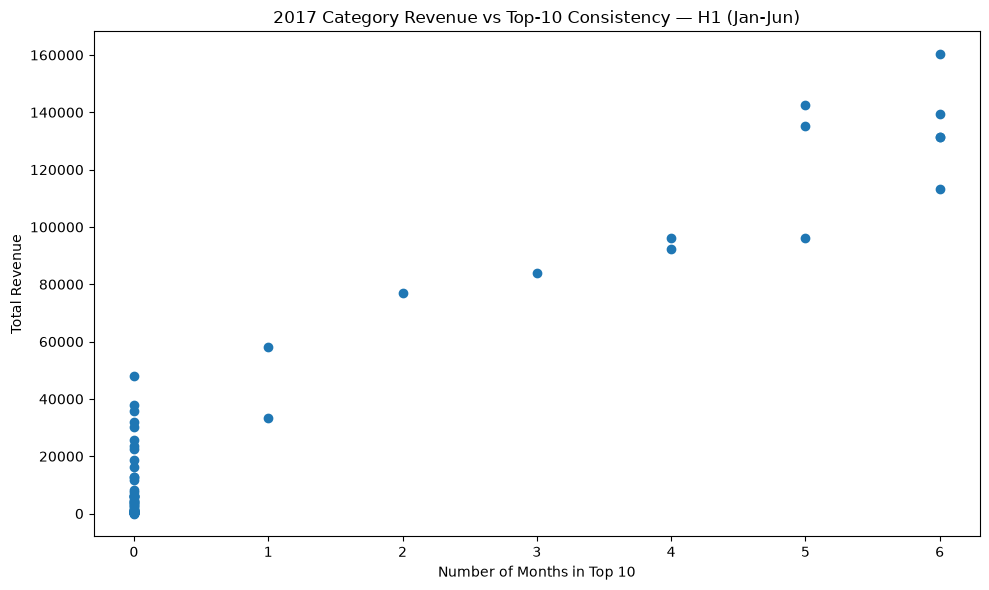

In [ ]:
plot_2017_category_consistency(category_summary_2017, "H1 (Jan-Jun)")

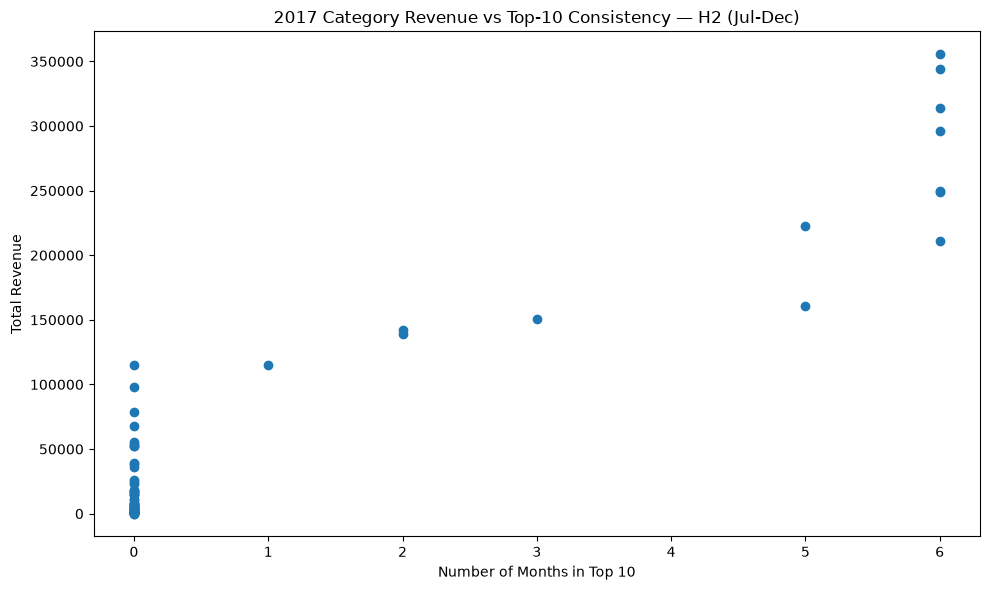

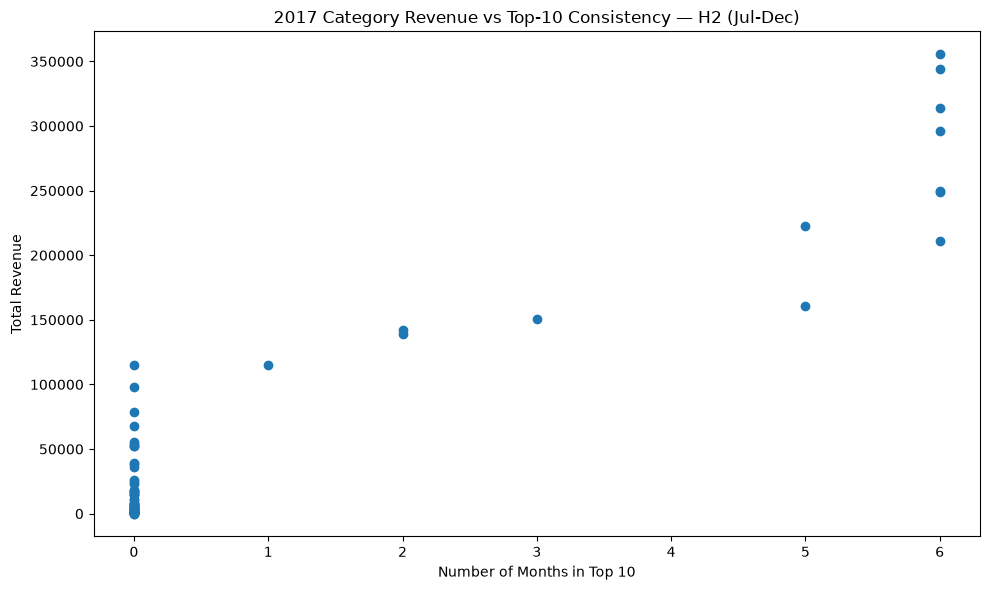

In [ ]:
plot_2017_category_consistency(category_summary_2017, "H2 (Jul-Dec)")